# Model Training

## Objective

Train multiple machine learning models and compare their performance using
Stratified Cross Validation.

Models:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

The best model is saved for inference.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

os.makedirs("../reports", exist_ok=True)
os.makedirs("../artifacts", exist_ok=True)

In [2]:
df = pd.read_csv("../artifacts/clean_dataset.csv")

print(df.shape)

df.head()

(4974, 12)


,Age,Gender,City,BMI,Heart_Rate,Cholesterol_Level,Diabetic,Smoker,Medications,Follow_Up,Diagnosis_Code,Has_Disease
0,250.0,NaN,boston,NaN,83.0,190.0,NaN,1.0,NaN,30.0,A00,0
1,250.0,male,los angeles,30.1,0.0,NaN,0.0,0.0,NaN,NaN,I10,1
2,-5.0,NaN,NaN,NaN,63.0,NaN,0.0,NaN,NaN,30.0,E11.9,0
3,250.0,NaN,boston,NaN,500.0,NaN,0.0,NaN,aspirin + metformin,30.0,NaN,0
4,-5.0,NaN,chicago,21.5,NaN,NaN,0.0,NaN,NaN,30.0,A00,1


In [28]:
print(df["Has_Disease"].groupby(df["Gender"]).mean())
print(df["Has_Disease"].groupby(df["Diagnosis_Code"]).mean())
print(df["Has_Disease"].groupby(df["City"]).mean())
print(df["Has_Disease"].groupby(df["Medications"]).mean())

Gender
female    0.497587
male      0.485258
Name: Has_Disease, dtype: float64
Diagnosis_Code
A00      0.487773
B20      0.513636
E11.9    0.494479
I10      0.485222
Name: Has_Disease, dtype: float64
City
boston         0.475610
chicago        0.493137
los angeles    0.496233
new york       0.500753
Name: Has_Disease, dtype: float64
Medications
aspirin + metformin       0.490623
lisinopril + metformin    0.506404
Name: Has_Disease, dtype: float64


In [3]:
X = df.drop("Has_Disease", axis=1)
y = df["Has_Disease"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
preprocessor = joblib.load("../artifacts/preprocessor.joblib")

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
results = []

trained_models = {}

In [9]:
for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    pipe.fit(X_train, y_train)

    trained_models[name] = pipe

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean()
    })

In [10]:
results = pd.DataFrame(results)

results = results.sort_values(
    by="ROC_AUC",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Gradient Boosting,0.521741,0.517694,0.481988,0.498916,0.531272
1,Decision Tree,0.503638,0.498712,0.470788,0.484275,0.504244
2,Random Forest,0.497361,0.492152,0.483998,0.487994,0.493521
0,Logistic Regression,0.497612,0.491312,0.436249,0.461649,0.490847
3,Extra Trees,0.499374,0.493728,0.470295,0.481694,0.488555


In [11]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [12]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [13]:
best_model = models[best_model_name]

In [14]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

In [15]:
param_distributions = {}

if best_model_name in ["Random Forest", "Extra Trees"]:

    param_distributions = {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(3, 30),
        "model__min_samples_split": randint(2, 15),
        "model__min_samples_leaf": randint(1, 10)
    }

elif best_model_name == "Decision Tree":

    param_distributions = {
        "model__max_depth": randint(3, 30),
        "model__min_samples_split": randint(2, 15),
        "model__min_samples_leaf": randint(1, 10)
    }

elif best_model_name == "Gradient Boosting":

    param_distributions = {
        "model__n_estimators": randint(100, 500),
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": randint(2, 8)
    }

elif best_model_name == "Logistic Regression":

    param_distributions = {
        "model__C": [0.01, 0.1, 1, 10, 100]
    }

In [16]:
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'BMI',
                                                                                'Heart_Rate',
                                                                                'Cholesterol_Level',
                                                                                'Diabetic',
                                                                                'Smoker']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',...
                                              GradientBoostingClassifier(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000252D9D37CB0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000252ECF0D460>},
                   random_state=42, scoring='roc_auc')

In [17]:
best_pipeline = search.best_estimator_

In [18]:
predictions = best_pipeline.predict(X_test)

probabilities = best_pipeline.predict_proba(X_test)[:, 1]

In [19]:
metrics = {
    "Accuracy": accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall": recall_score(y_test, predictions),
    "F1": f1_score(y_test, predictions),
    "ROC_AUC": roc_auc_score(y_test, probabilities)
}

metrics

{'Accuracy': 0.4834170854271357,
 'Precision': 0.47708333333333336,
 'Recall': 0.4654471544715447,
 'F1': 0.4711934156378601,
 'ROC_AUC': 0.47519961531623267}

In [20]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.49      0.50      0.50       503
           1       0.48      0.47      0.47       492

    accuracy                           0.48       995
   macro avg       0.48      0.48      0.48       995
weighted avg       0.48      0.48      0.48       995



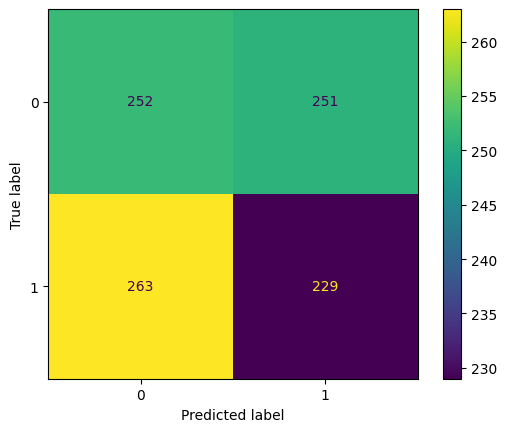

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.savefig("../reports/confusion_matrix.png")

plt.show()

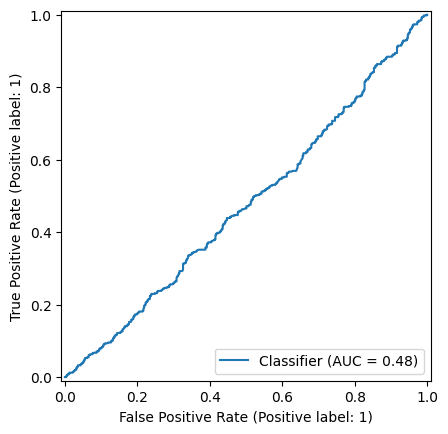

In [22]:
RocCurveDisplay.from_predictions(
    y_test,
    probabilities
)

plt.savefig("../reports/roc_curve.png")

plt.show()

In [23]:
if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):

    feature_names = best_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_pipeline.named_steps["model"].feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    importance.to_csv(
        "../reports/feature_importance.csv",
        index=False
    )

    print(importance.head(20))

                                    Feature  Importance
1                                  num__BMI    0.273291
0                                  num__Age    0.169327
2                           num__Heart_Rate    0.161423
5                               num__Smoker    0.039940
4                             num__Diabetic    0.036732
3                    num__Cholesterol_Level    0.029350
16                  cat__Diagnosis_Code_A00    0.028356
9                         cat__City_chicago    0.028197
10                    cat__City_los angeles    0.025384
18                cat__Diagnosis_Code_E11.9    0.024980
17                  cat__Diagnosis_Code_B20    0.024232
19                  cat__Diagnosis_Code_I10    0.023463
6                        cat__Gender_female    0.021522
8                          cat__City_boston    0.021375
7                          cat__Gender_male    0.020965
15                      cat__Follow_Up_30.0    0.019225
14                      cat__Follow_Up_14.0    0

In [24]:
joblib.dump(
    best_pipeline,
    "../artifacts/best_pipeline.joblib"
)

with open("../artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [25]:
print("=" * 50)
print("Training Completed Successfully")
print("=" * 50)

print("\nBest Model:", best_model_name)

print("\nMetrics:")

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Training Completed Successfully

Best Model: Gradient Boosting

Metrics:
Accuracy: 0.4834
Precision: 0.4771
Recall: 0.4654
F1: 0.4712
ROC_AUC: 0.4752


# Training Completed

Successfully

- Compared four machine learning models
- Used 5-fold Stratified Cross Validation
- Evaluated on unseen test data
- Saved model comparison table
- Saved metrics.json
- Saved best_pipeline.joblib

The trained pipeline is now ready for inference.